### Visualize Stocks Data With Raw MongoDB Queries

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mongoengine import connect, Document, StringField, FloatField, DateTimeField
import datetime

connect('stock_alert_db', host='mongodb://localhost:27017/stock_alert_db')

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, read_preference=Primary(), uuidrepresentation=3, driver=DriverInfo(name='MongoEngine', version='0.29.3', platform=None))

In [15]:
class StockLevel(Document):
    ticker = StringField(required=True)
    price = FloatField(required=True)
    timestamp = DateTimeField(default=datetime.datetime.utcnow)

    # Explicitly map to your existing collection
    meta = {"collection": "stock_levels"}

In [16]:
import datetime
import random


def seed_database():
    print("Clearing old data...")
    StockLevel.objects().delete()  # Clear existing to avoid duplicates during testing

    print("Generating synthetic stock data...")
    ticker = "RELIANCE.NS"
    base_price = 2500.0

    # Generate 50 data points over the last 50 hours
    now = datetime.datetime.now(datetime.UTC)
    for i in range(50):
        # Add some random walk volatility
        price_fluctuation = random.uniform(-15.0, 20.0)
        base_price += price_fluctuation

        timestamp = now - datetime.timedelta(hours=50 - i)

        # Save to MongoDB
        StockLevel(ticker=ticker, price=base_price, timestamp=timestamp).save()

    print("Database seeded successfully! You can now re-run your visualization cell.")


# Execute the seeder
seed_database()

Clearing old data...
Generating synthetic stock data...
Database seeded successfully! You can now re-run your visualization cell.


In [17]:
# Example: Raw query to fetch levels for a specific ticker above a certain price threshold
raw_query = {"ticker": "RELIANCE.NS", "price": {"$gte": 2500}}

# Execute the raw query and sort chronologically
results = StockLevel.objects(__raw__=raw_query).order_by("timestamp")

# Map the objects to a list of dictionaries for Pandas
data = [
    {"Ticker": item.ticker, "Price": item.price, "Time": item.timestamp}
    for item in results
]

df = pd.DataFrame(data)

# Display the first few rows to verify the structure
df.head()

,Ticker,Price,Time
0,RELIANCE.NS,2503.748689,2026-03-24 09:07:58.642
1,RELIANCE.NS,2507.246065,2026-03-24 10:07:58.642
2,RELIANCE.NS,2507.470295,2026-03-24 11:07:58.642
3,RELIANCE.NS,2522.688572,2026-03-24 12:07:58.642
4,RELIANCE.NS,2529.142986,2026-03-24 13:07:58.642


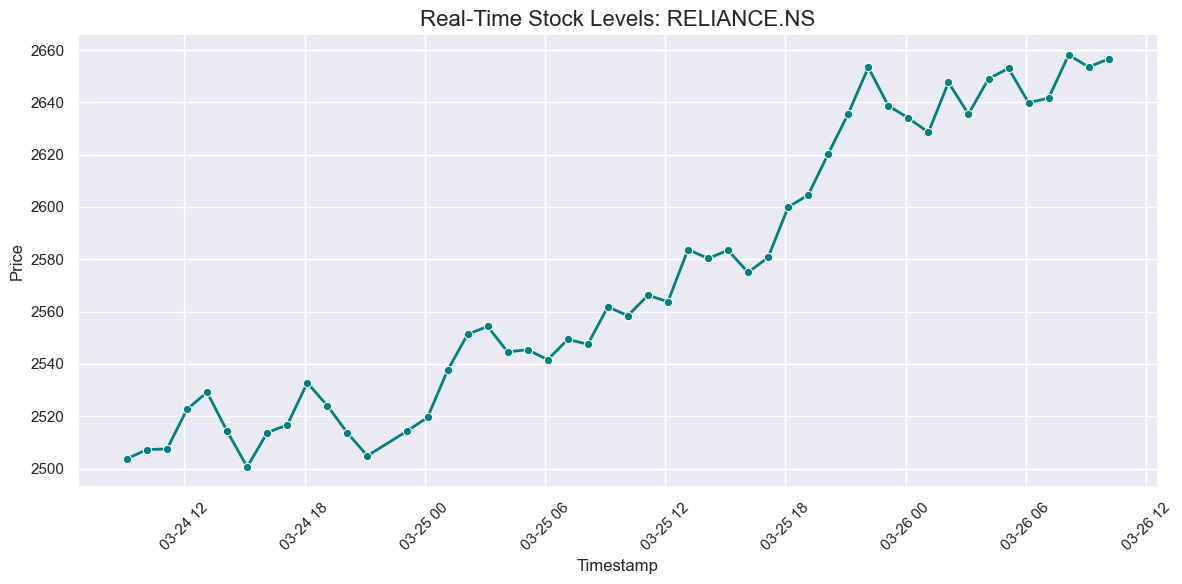

In [18]:

if not df.empty:
    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(12, 6))

    sns.lineplot(data=df, x="Time", y="Price", marker="o", color="teal", linewidth=2)

    plt.title(f"Real-Time Stock Levels: {df['Ticker'].iloc[0]}", fontsize=16)
    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("No data found for this query. The DataFrame is empty.")

Clearing old data...
Generating synthetic stock data...
Database seeded successfully! You can now re-run your visualization cell.
